# ME/MSE 4710 Lecture 11 Building Machine Learning Models in Python

In this lecture, we will build Neural Networks to solve two real-world problems:

Classification: Breast Cancer Diagnosis
Regression: Concrete Compressive Strength Prediction

The goal of this lecture is to understand the end-to-end workflow for building a machine learning model in Python, including:

$$ \boxed{ \text{Load Data} \rightarrow \text{Prepare Data} \rightarrow \text{Build Model} \rightarrow \text{Train Model} \rightarrow \text{Make Predictions} \rightarrow \text{Evaluate Performance} } $$


Note: Today we focus on the big picture and implementation workflow. Each step, such as data preprocessing, model selection, training, validation, and evaluation, will be discussed in greater detail in later lectures.

# 1 Breast Cancer Diagnosis classification problem

### Step 1: Load the data

In [1]:
# Import all libraries
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Load data
data = load_breast_cancer()

# .data and .target work because load_breast_cancer() returns a Bunch object,
# which is similar to a dictionary. The data contains the features, and target contains the labels.
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("X shape:", X.shape)
print("\nClasses:")
print(dict(enumerate(data.target_names)))

X.head()

X shape: (569, 30)

Classes:
{0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
type(data.data)

numpy.ndarray

In [4]:
print(data)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,

In [5]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [6]:
# Print the size of data
print("X shape:", X.shape)
print("y shape:", y.shape)  # one-dimensional array with 569 elements
print("Classes:", data.target_names)

X shape: (569, 30)
y shape: (569,)
Classes: ['malignant' 'benign']


### Step 2: Prepare data

In [7]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,  # industry standard 80/20 split for training and testing
    random_state=42,  # For reproducibility and can make the comparison more meaningful
    stratify=y,  # Keep class proportions (1s and 0s) in train and test sets as original dataset
)

Before training the model, we often scale our features because different features can have very different numerical ranges. Scaling makes the loss surface more balanced across different parameter directions, allowing gradient descent to reach the minimum more efficiently. A large numerical value does not necessarily mean that feature is more important.
StandardScaler puts the features onto a comparable numerical scale.

In [8]:
# scale the data
scaler = StandardScaler()

# fit learns the preprocessing parameters; transform applies the learned parameters to the data
# We learn the ruler from the training data and use the same ruler for all future data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Besides the standardization, another method we usually apply is Min-Max normalization: $
x'=\frac{x-x_{\min}}{x_{\max}-x_{\min}}
$

This would be just:
```
scaler = MinMaxScaler()
```

In [9]:
X_train[:1]  # First row of the training data

array([[-1.07200079e+00, -6.58424598e-01, -1.08808010e+00,
        -9.39273639e-01, -1.35939882e-01, -1.00871795e+00,
        -9.68358632e-01, -1.10203235e+00,  2.81062120e-01,
        -1.13231479e-01, -7.04860874e-01, -4.40938351e-01,
        -7.43948977e-01, -6.29804931e-01,  7.48061001e-04,
        -9.91572979e-01, -6.93759567e-01, -9.83284458e-01,
        -5.91579010e-01, -4.28972052e-01, -1.03409427e+00,
        -6.23497432e-01, -1.07077336e+00, -8.76534437e-01,
        -1.69982346e-01, -1.03883630e+00, -1.07899452e+00,
        -1.35052668e+00, -3.52658049e-01, -5.41380026e-01]])

In [10]:
print(type(X_train))
print(type(X_test))
print(type(y_train))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [11]:
X_train = torch.tensor(X_train, dtype=torch.float32)  # Convert the data to a PyTorch tensor
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.to_numpy(), dtype=torch.float32).reshape(
    -1, 1
)  # reshape to make column vector
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.float32).reshape(
    -1, 1
)  # to use in loss function

Here we converted the labels to float32 because binary cross-entropy compares the model's floating-point probabilities with the target values 0.0 and 1.0.”


What does .reshape(-1, 1) mean?
original shape of y is (455,) 1D vector, 455 elements. In neural network, if we have 455 samples, the netwrok output has shape (455,1). In order to make two size matches, we need reshape the output.

reshape(-1, 1) forces the one-dimensional (455,) tensor into the two-dimensional (455, 1) shape, matching the model's output. The -1 means "let PyTorch figure out this dimension automatically", which is the number of samples, 455.

In [12]:
type(X_train)

torch.Tensor

In [13]:
print(y_train[:5])  # First 5 elements of the training labels
print(y_test[:5])  # First 5 elements of the test labels

tensor([[1.],
        [0.],
        [1.],
        [1.],
        [1.]])
tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])


In [14]:
print(f"y_train.shape: {y_train.shape}")  # Shape of the training labels
print(f"y_test.shape: {y_test.shape}")  # Shape of the test labels

y_train.shape: torch.Size([455, 1])
y_test.shape: torch.Size([114, 1])


### Step 3: Build the model

In [15]:
class ClassificationNN(nn.Module):  # extends nn.Module base class for neural networks in PyTorch
    def __init__(self):
        super().__init__()  # initializes the PyTorch nn framework before we define layers

        self.network = nn.Sequential(  # pass data through layers one after another, in order listed
            # Hidden layer 1
            nn.Linear(30, 16),
            nn.LeakyReLU(0.1),  # leaky to avoid dying neurons
            # Hidden layer 2
            nn.Linear(16, 8),
            nn.ReLU(),
            # Output layer
            nn.Linear(8, 1),
            nn.Sigmoid(),  # binary classification and we only need one neuron on output layer
        )

    def forward(self, x):
        return self.network(x)  # forward propagation through network; x input

In [16]:
model = ClassificationNN()  # instance of NN
print(model)

ClassificationNN(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=16, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [17]:
for name, param in model.named_parameters():
    print(name, param.shape)  # name is network.layer.weight/bias

network.0.weight torch.Size([16, 30])
network.0.bias torch.Size([16])
network.2.weight torch.Size([8, 16])
network.2.bias torch.Size([8])
network.4.weight torch.Size([1, 8])
network.4.bias torch.Size([1])


In [18]:
criterion = nn.BCELoss()  # loss function: binary cross-entropy loss for binary classifcation
# BCELoss is used for binary classification problems where the target is a binary value (0 or 1)

optimizer = optim.Adam(
    model.parameters(), lr=0.001
)  # Adam is industry standard optimizer. adaptive lr based on first and second moments

### Step 4: Train model

In [19]:
num_epochs = 200
loss_history = []  # empty list to store loss
test_loss_history = []  # empty list to store test loss

# Using patience to stop training if loss does not improve for a certain number of epochs
patience = 10  # number of epochs to wait for improvement before stopping
best_loss = float("inf")  # initialize best loss to infinity
patience_counter = 0  # counter for epochs without improvement

for epoch in range(num_epochs):
    # 1. Clear old gradients
    optimizer.zero_grad()

    # 2. Forward propagation: make prediction
    outputs = model(X_train)

    # 3. Compute loss
    loss = criterion(outputs, y_train)  # pytorch function using our defined BCELoss()

    # 4. Backpropagation: compute gradient
    loss.backward()

    # 5. Update weights and biases
    optimizer.step()

    loss_history.append(loss.item())

    # 6. Test validation loss
    with torch.no_grad():  # no need to compute gradients for validation; faster and saves memory
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test)
        test_loss_history.append(test_loss.item())

    # 7. Print loss every 20 epochs
    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train Loss = {loss.item():.4f}"
            f" | Test Loss = {test_loss.item():.4f}"
        )

    # 8. Early stopping
    if test_loss.item() < best_loss:
        best_loss = test_loss.item()
        best_model_state = model.state_dict()  # save the best model state
        patience_counter = 0  # reset counter if loss improves
    else:
        patience_counter += 1  # increment counter if no improvement

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}; best test loss: {best_loss:.4f}")
        break

model.load_state_dict(best_model_state)  # load the best model state after training

Epoch  20 | Train Loss = 0.6125 | Test Loss = 0.6129
Epoch  40 | Train Loss = 0.5265 | Test Loss = 0.5285
Epoch  60 | Train Loss = 0.4273 | Test Loss = 0.4331
Epoch  80 | Train Loss = 0.3353 | Test Loss = 0.3463
Epoch 100 | Train Loss = 0.2575 | Test Loss = 0.2748
Epoch 120 | Train Loss = 0.1952 | Test Loss = 0.2181
Epoch 140 | Train Loss = 0.1491 | Test Loss = 0.1757
Epoch 160 | Train Loss = 0.1182 | Test Loss = 0.1470
Epoch 180 | Train Loss = 0.0975 | Test Loss = 0.1288
Epoch 200 | Train Loss = 0.0837 | Test Loss = 0.1163


<All keys matched successfully>

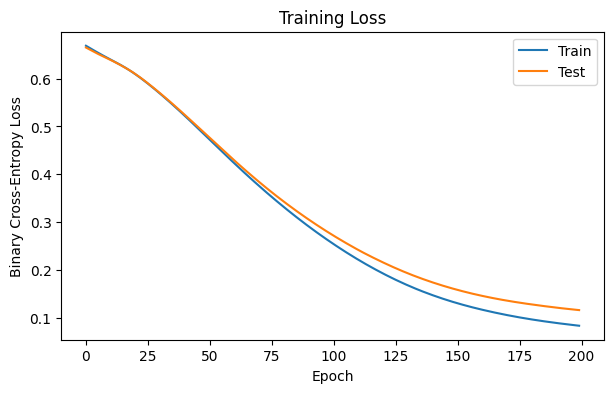

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(loss_history)
ax.plot(test_loss_history)
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary Cross-Entropy Loss")
ax.set_title("Training Loss")
ax.legend(["Train", "Test"])
plt.show()

### Step 5: Make the prediction

In [21]:
with torch.no_grad():
    probabilities = model(X_test)
    predictions = (probabilities >= 0.5).float()  # Convert probabilities into classes (0 or 1)

In [22]:
# Print prediction results
print("Probability | Predicted Label | True Label")
print("-" * 43)

for prob, pred, true in zip(  # zip() puts corresponding values together
    probabilities.numpy().flatten()[:10],
    predictions.numpy().flatten()[:10],
    y_test.numpy().flatten()[:10],
    strict=False,
):
    print(f"{prob:11.4f} | {int(pred):15d} | {int(true):10d}")

Probability | Predicted Label | True Label
-------------------------------------------
     0.0000 |               0 |          0
     0.9974 |               1 |          1
     0.0367 |               0 |          0
     0.5134 |               1 |          1
     0.0000 |               0 |          0
     0.9728 |               1 |          1
     0.9912 |               1 |          1
     0.0004 |               0 |          0
     0.0023 |               0 |          0
     0.0000 |               0 |          0


### Step 6: Evaluate performance

In [23]:
accuracy = accuracy_score(
    y_test.numpy(),
    predictions.numpy(),  # convert from tensor back to numpy format
)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9649122807017544


# 2 Concrete Compressive Strength Prediction Regression Problem

In [24]:
# install required library
!pip install ucimlrepo

### STEP 1: Load Data

In [25]:
from ucimlrepo import fetch_ucirepo

concrete = fetch_ucirepo(id=165)

X = concrete.data.features
y = concrete.data.targets.squeeze()

print(X.shape)
X.head()

(1030, 8)


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


In [26]:
y.head()

0    79.99
1    61.89
2    40.27
3    41.05
4    44.30
Name: Concrete compressive strength, dtype: float64

### Step2: Prepare Data

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 824
Testing samples: 206


In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)

y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

In [30]:
print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

X_train: torch.Size([824, 8])
y_train: torch.Size([824, 1])


### Step 3: Build Model

In [31]:
class RegressionNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(8, 32), nn.ReLU(), nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

In [32]:
model = RegressionNN()

print(model)

RegressionNN(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [33]:
for name, param in model.named_parameters():
    print(name, param.shape)

network.0.weight torch.Size([32, 8])
network.0.bias torch.Size([32])
network.2.weight torch.Size([16, 32])
network.2.bias torch.Size([16])
network.4.weight torch.Size([1, 16])
network.4.bias torch.Size([1])


In [34]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total trainable parameters:", total_params)

Total trainable parameters: 833


In [35]:
# criterion = nn.MSELoss()
criterion = nn.L1Loss()

In [36]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Step 4: Train Model

In [37]:
num_epochs = 2000

loss_history = []

for epoch in range(num_epochs):
    optimizer.zero_grad()

    y_pred = model(X_train_tensor)

    loss = criterion(y_pred, y_train_tensor)

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1:4d} | MSE Loss = {loss.item():.4f}")

Epoch  100 | MSE Loss = 30.2078
Epoch  200 | MSE Loss = 13.5670
Epoch  300 | MSE Loss = 11.0876
Epoch  400 | MSE Loss = 10.1686
Epoch  500 | MSE Loss = 9.4450
Epoch  600 | MSE Loss = 8.7764
Epoch  700 | MSE Loss = 8.0730
Epoch  800 | MSE Loss = 7.2542
Epoch  900 | MSE Loss = 6.3723
Epoch 1000 | MSE Loss = 5.6137
Epoch 1100 | MSE Loss = 4.9553
Epoch 1200 | MSE Loss = 4.5011
Epoch 1300 | MSE Loss = 4.2579
Epoch 1400 | MSE Loss = 4.1165
Epoch 1500 | MSE Loss = 3.9787
Epoch 1600 | MSE Loss = 3.8334
Epoch 1700 | MSE Loss = 3.6934
Epoch 1800 | MSE Loss = 3.5751
Epoch 1900 | MSE Loss = 3.4668
Epoch 2000 | MSE Loss = 3.3725


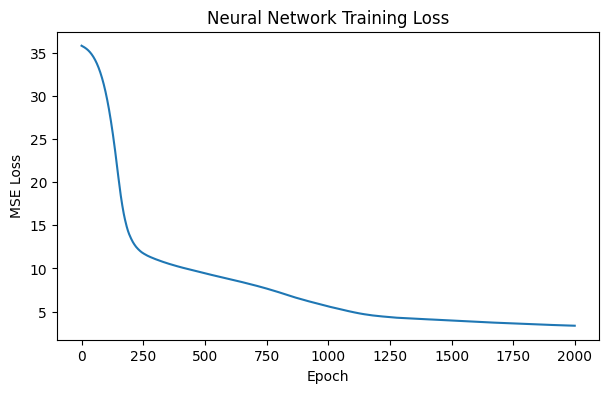

In [38]:
plt.figure(figsize=(7, 4))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Neural Network Training Loss")

plt.show()

### Step 5: Make Prediction

In [39]:
model.eval()

with torch.no_grad():
    y_pred_test = model(X_test_tensor)

In [40]:
y_pred_test = y_pred_test.numpy().flatten()
y_test_np = y_test_tensor.numpy().flatten()

### Step 6: Evaluate Model

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mse = mean_squared_error(y_test_np, y_pred_test)

mae = mean_absolute_error(y_test_np, y_pred_test)

r2 = r2_score(y_test_np, y_pred_test)

print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f} MPa")
print(f"Test R²:  {r2:.3f}")

Test MSE: 31.49
Test MAE: 4.29 MPa
Test R²:  0.878


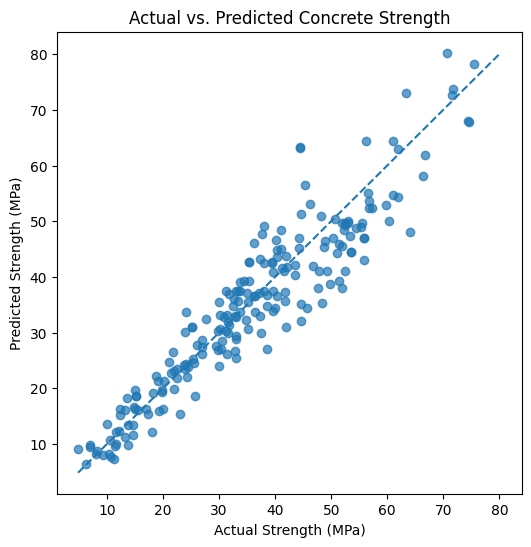

In [42]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test_np, y_pred_test, alpha=0.7)

min_value = min(y_test_np.min(), y_pred_test.min())

max_value = max(y_test_np.max(), y_pred_test.max())

plt.plot([min_value, max_value], [min_value, max_value], "--")

plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Actual vs. Predicted Concrete Strength")

plt.show()